In [1]:
import os
import time

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.stats import spearmanr
from astropy.cosmology import Planck13
import importlib

import utils.data as datutils
import utils.plots as plots
import utils.file as futils

import warnings
from pandas.errors import ParserWarning

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

In [2]:
m14 = pd.read_csv('data/gadgetx3k/mag_diff_GadgetX_3k.csv')
m14.set_index('ID', inplace=True)

In [3]:
dsdict = futils.get_ds_all()
for df in dsdict.values():
    df['m14'] = m14['3d'].values

In [4]:
seed = list(range(100))
percs_200 = []
percs_500 = []
for snap in dsdict.keys():
    df = dsdict[snap]
    df = df.drop(columns=['snap'])
    sample_size = len(df)
    corrs_list = [df.sample(n=sample_size, replace=True,
                            random_state=s).corr(method='spearman')
        for s in seed
    ]
    p10_200 = np.percentile(corrs_list, 10, axis=0)[2]
    p25_200 = np.percentile(corrs_list, 25, axis=0)[2]
    p50_200 = np.percentile(corrs_list, 50, axis=0)[2]
    p75_200 = np.percentile(corrs_list, 75, axis=0)[2]
    p90_200 = np.percentile(corrs_list, 90, axis=0)[2]
    percs_200.append((p10_200, p25_200, p50_200, p75_200, p90_200))

    p10_500 = np.percentile(corrs_list, 10, axis=0)[6]
    p25_500 = np.percentile(corrs_list, 25, axis=0)[6]
    p50_500 = np.percentile(corrs_list, 50, axis=0)[6]
    p75_500 = np.percentile(corrs_list, 75, axis=0)[6]
    p90_500 = np.percentile(corrs_list, 90, axis=0)[6]
    percs_500.append((p10_500, p25_500, p50_500, p75_500, p90_500))

percs_200 = np.array(percs_200)
percs_500 = np.array(percs_500)

In [6]:
redshift_list = pd.read_csv('data/gadgetx3k/redshift_list.txt', sep=r'\s+')

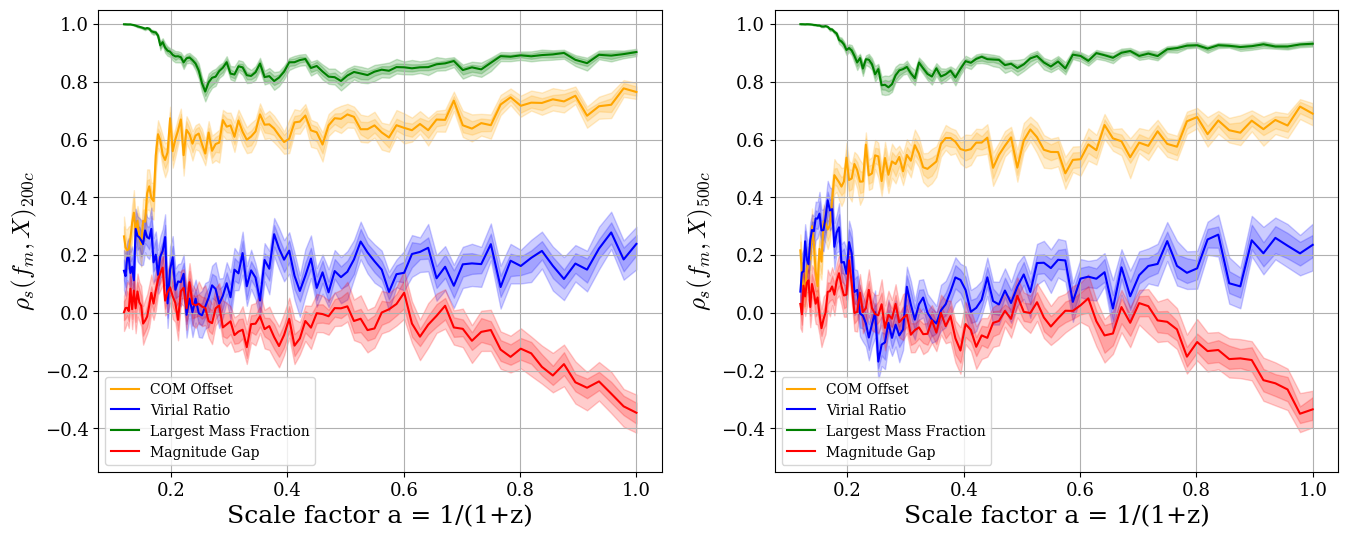

In [7]:
yticks = np.arange(-0.4, 1.2, 0.2)
ylim = (-0.55, 1.05)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
scales = redshift_list[32:]['a'].values

axs[0].plot(scales, percs_200[:, 2, 1], color='orange', label='COM Offset')
axs[0].fill_between(scales, percs_200[:, 1, 1],
                 percs_200[:, 3, 1], color='orange', alpha=0.2)
axs[0].fill_between(scales, percs_200[:, 0, 1],
                 percs_200[:, 4, 1], color='orange', alpha=0.2)

axs[0].plot(scales, percs_200[:, 2, 0], color='blue', label='Virial Ratio')
axs[0].fill_between(scales, percs_200[:, 1, 0],
                 percs_200[:, 3, 0], color='blue', alpha=0.2)
axs[0].fill_between(scales, percs_200[:, 0, 0],
                 percs_200[:, 4, 0], color='blue', alpha=0.2)

axs[0].plot(scales, percs_200[:, 2, 3], color='green', label='Largest Mass Fraction')
axs[0].fill_between(scales, percs_200[:, 1, 3],
                 percs_200[:, 3, 3], color='green', alpha=0.2)
axs[0].fill_between(scales, percs_200[:, 0, 3],
                 percs_200[:, 4, 3], color='green', alpha=0.2)
                
axs[0].plot(scales, percs_200[:, 2, 8], color='red',
            label='Magnitude Gap')
axs[0].fill_between(scales, percs_200[:, 1, 8],
                    percs_200[:, 3, 8], color='red', alpha=0.2)
axs[0].fill_between(scales, percs_200[:, 0, 8],
                    percs_200[:, 4, 8], color='red', alpha=0.2)

axs[0].grid()
axs[0].legend(loc='lower left')
axs[0].set_xlabel('Scale factor a = 1/(1+z)')
axs[0].set_ylabel(r'$\rho_s (f_m, X)_{200c}$')
axs[0].set_yticks(yticks)
axs[0].set_ylim(ylim)

axs[1].plot(scales, percs_200[:, 2, 5], color='orange', label='COM Offset')
axs[1].fill_between(scales, percs_200[:, 1, 5],
                    percs_200[:, 3, 5], color='orange', alpha=0.2)
axs[1].fill_between(scales, percs_200[:, 0, 5],
                    percs_200[:, 4, 5], color='orange', alpha=0.2)

axs[1].plot(scales, percs_500[:, 2, 4], color='blue', label='Virial Ratio')
axs[1].fill_between(scales, percs_500[:, 1, 4],
                    percs_500[:, 3, 4], color='blue', alpha=0.2)
axs[1].fill_between(scales, percs_500[:, 0, 4],
                    percs_500[:, 4, 4], color='blue', alpha=0.2)

axs[1].plot(scales, percs_500[:, 2, 7], color='green',
            label='Largest Mass Fraction')
axs[1].fill_between(scales, percs_500[:, 1, 7],
                    percs_500[:, 3, 7], color='green', alpha=0.2)
axs[1].fill_between(scales, percs_500[:, 0, 7],
                    percs_500[:, 4, 7], color='green', alpha=0.2)

axs[1].plot(scales, percs_500[:, 2, 8], color='red',
            label='Magnitude Gap')
axs[1].fill_between(scales, percs_500[:, 1, 8],
                    percs_500[:, 3, 8], color='red', alpha=0.2)
axs[1].fill_between(scales, percs_500[:, 0, 8],
                    percs_500[:, 4, 8], color='red', alpha=0.2)

axs[1].set_xlabel('Scale factor a = 1/(1+z)')
axs[1].set_ylabel(r'$\rho_s (f_m, X)_{500c}$')
axs[1].set_yticks(yticks)
axs[1].set_ylim(ylim)
axs[1].grid()
axs[1].legend(loc='lower left')

plt.savefig('plots/dsds.pdf')
plt.show()

In [96]:
def plot_2dcorr(corr_matrix, scales, xlabel, ylabel, title='', ax=None):
    cmap = plt.get_cmap('bwr', 10)                   # 10 discrete color bins
    boundaries = np.linspace(-1.0, 1.0, 11)             # 10 bins -> 11 boundaries
    norm = mpl.colors.BoundaryNorm(boundaries, cmap.N, clip=True)

    im = ax.imshow(corr_matrix, origin='lower',
                extent=[0.25, 1, 0.25, 1],
                cmap=cmap, norm=norm,
                interpolation='nearest', aspect='auto')

    ax.plot(scales, scales, color='black', linestyle='-', linewidth=1)
    # ax.grid(True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    return im, boundaries

In [6]:
dsdict = futils.get_ds_all()

dsdict_200 = {}
dsdict_500 = {}
for snap, df in dsdict.items():
    dsdict_200[snap] = df.drop(columns=['snap', 'eta_500[8]',
                                        'delta_500[9]', 'fm_500[10]', 'fm2_500[11]'])
    dsdict_500[snap] = df.drop(columns=['snap', 'eta_200[3]',
                                        'delta_200[4]', 'fm_200[5]', 'fm2_200[6]'])

In [328]:
fm_corrs = []
for snap, df in dsdict_200.items():
    fm200 = df['fm_200[5]'].values
    for time, df1 in dsdict_200.items():
        df1 = df1.copy()
        df1['fm_200'] = fm200
        corr = df1.corr(method='spearman')
        fm_corrs.append(corr['fm_200'].values)  

fm_corrs = np.array(fm_corrs)
fm_corrs = fm_corrs.reshape(97, 97, 5)  # n_snaps, n_snaps, n_features

In [329]:
eta200c = fm_corrs[:, :, 0]
delta200c = fm_corrs[:, :, 1]
fm200c = fm_corrs[:, :, 2]
fm2200c = fm_corrs[:, :, 3]

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_24171/3210505093.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar


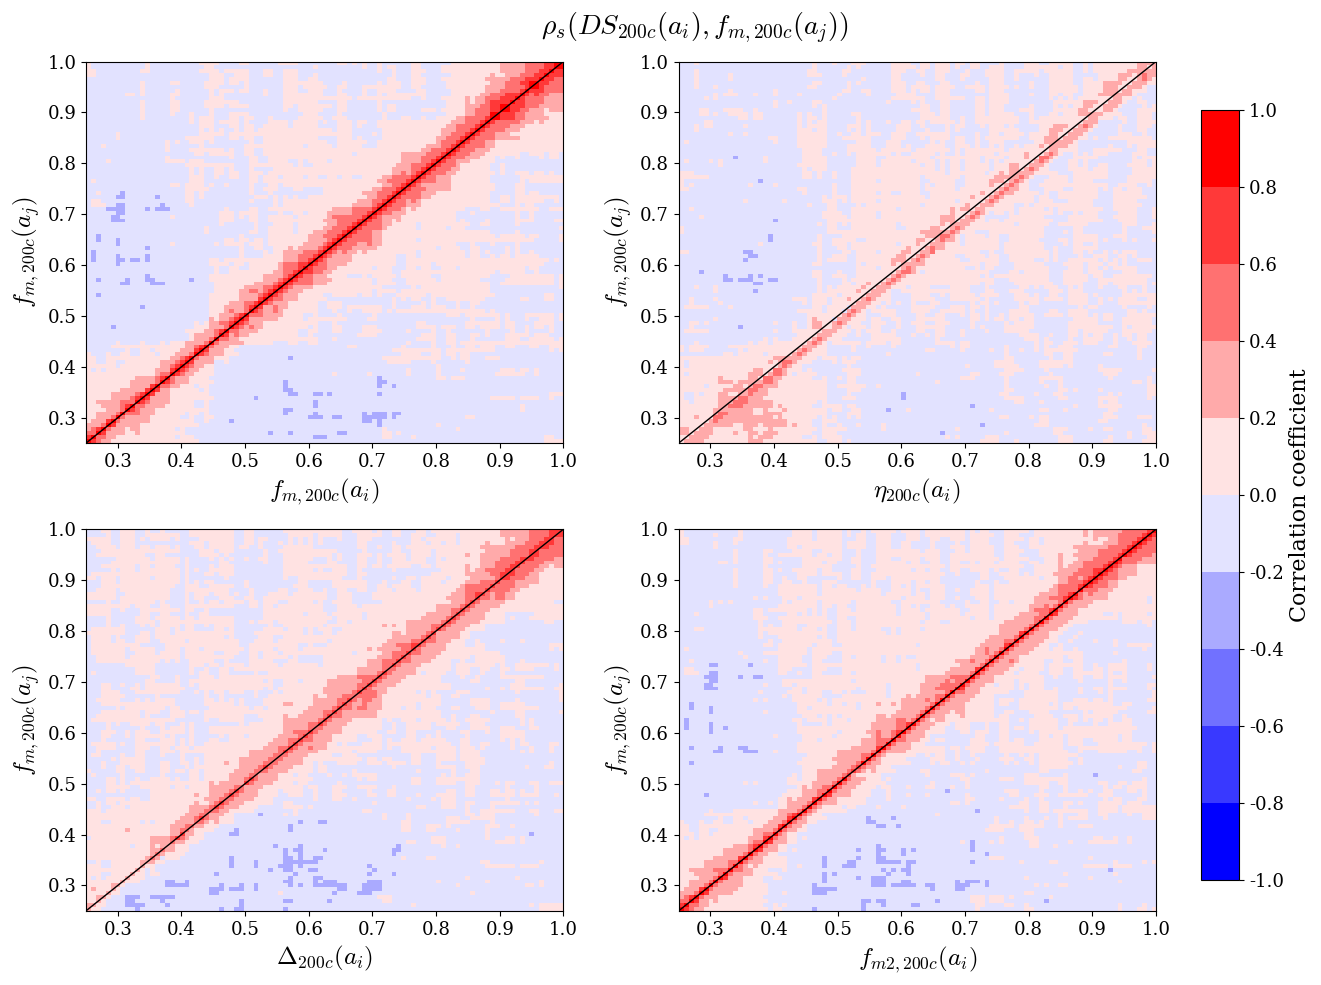

In [330]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

plot_2dcorr(fm200c, xlabel=r'$f_{m, 200c}(a_i)$',
            ylabel=r'$f_{m, 200c}(a_j)$',
            ax=axs[0, 0])

plot_2dcorr(eta200c, xlabel=r'$\eta_{200c}(a_i)$',
            ylabel=r'$f_{m, 200c}(a_j)$',
            ax=axs[0, 1])

plot_2dcorr(delta200c, xlabel=r'$\Delta_{200c}(a_i)$',
            ylabel=r'$f_{m, 200c}(a_j)$',
            ax=axs[1, 0])

# Get handle to the image from the last plot
im, boundaries = plot_2dcorr(fm2200c, xlabel=r'$f_{m2, 200c}(a_i)$',
                             ylabel=r'$f_{m, 200c}(a_j)$',
                             ax=axs[1, 1])

# Adjust layout before adding colorbar

# Add colorbar spanning all subplots
cbar = fig.colorbar(im, ax=axs.ravel().tolist(),
                    boundaries=boundaries, ticks=boundaries,
                    location='right', fraction=0.05)

cbar.ax.set_yticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label('Correlation coefficient', fontsize=16)
fig.suptitle(r'$\rho_s (DS_{200c}(a_i), f_{m, 200c}(a_j))$', fontsize=20)

plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar
# plt.savefig('plots/ds_fm_200c.pdf')
plt.show()

In [297]:
fm_corrs = []
for snap, df in dsdict_500.items():
    fm500 = df['fm_500[10]'].values
    for time, df1 in dsdict_500.items():
        df1 = df1.copy()
        df1['fm_500'] = fm500
        corr = df1.corr(method='spearman')
        fm_corrs.append(corr['fm_500'].values)

fm_corrs = np.array(fm_corrs)
fm_corrs = fm_corrs.reshape(97, 97, 5)  # n_snaps, n_snaps, n_features

In [298]:
eta500c = fm_corrs[:, :, 0]
delta500c = fm_corrs[:, :, 1]
fm500c = fm_corrs[:, :, 2]
fm2500c = fm_corrs[:, :, 3]

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_24171/3086948630.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar


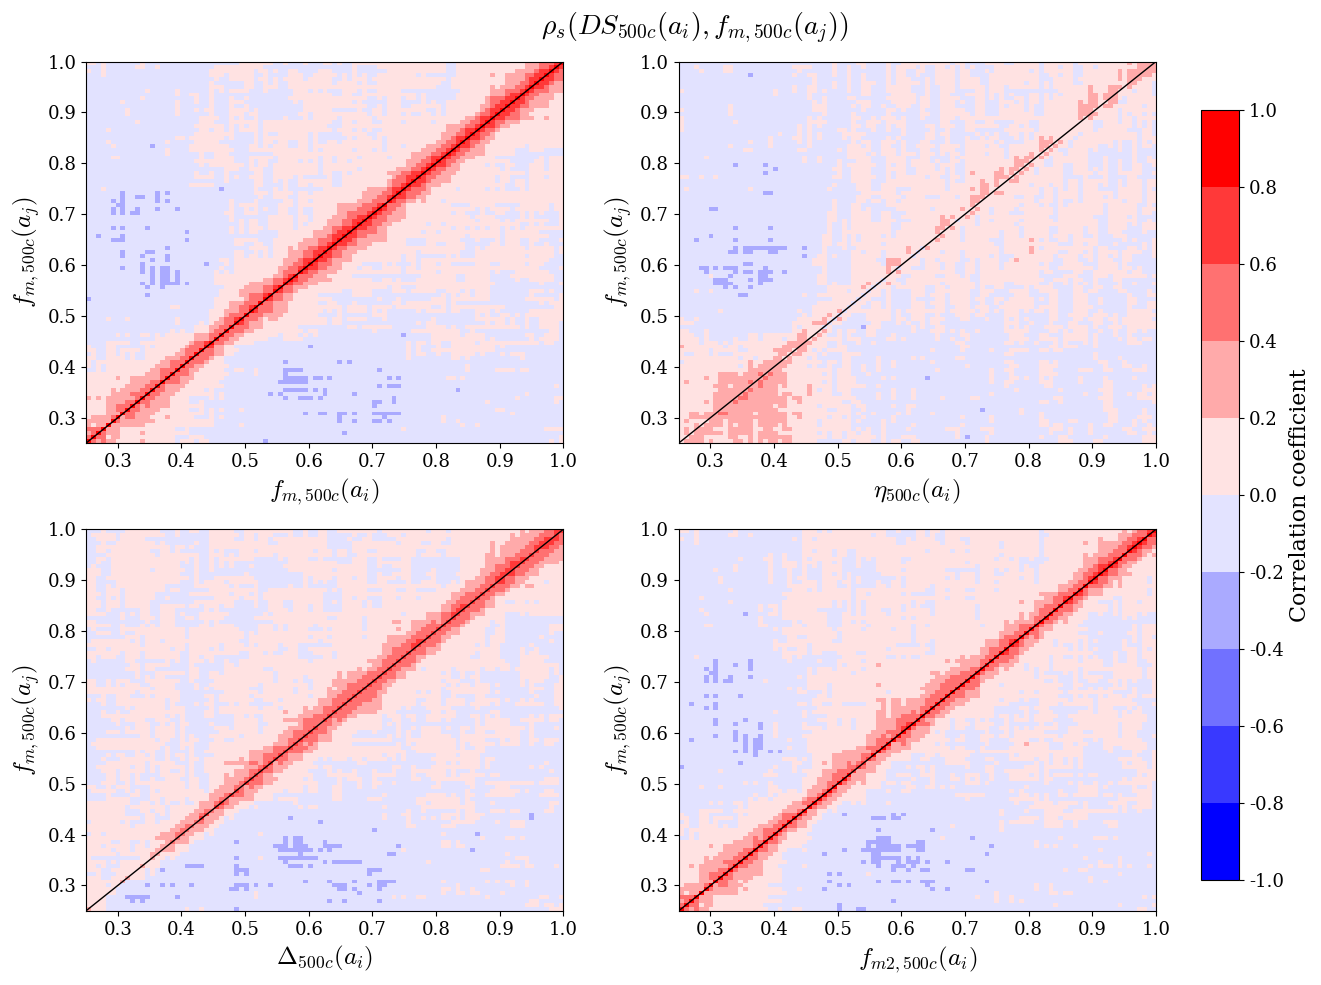

In [301]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

plot_2dcorr(fm500c, xlabel=r'$f_{m, 500c}(a_i)$',
            ylabel=r'$f_{m, 500c}(a_j)$',
            ax=axs[0, 0])

plot_2dcorr(eta500c, xlabel=r'$\eta_{500c}(a_i)$',
            ylabel=r'$f_{m, 500c}(a_j)$',
            ax=axs[0, 1])

plot_2dcorr(delta500c, xlabel=r'$\Delta_{500c}(a_i)$',
            ylabel=r'$f_{m, 500c}(a_j)$',
            ax=axs[1, 0])

# Get handle to the image from the last plot
im, boundaries = plot_2dcorr(fm2500c, xlabel=r'$f_{m2, 500c}(a_i)$',
                             ylabel=r'$f_{m, 500c}(a_j)$',
                             ax=axs[1, 1])

# Adjust layout before adding colorbar

# Add colorbar spanning all subplots
cbar = fig.colorbar(im, ax=axs.ravel().tolist(),
                    boundaries=boundaries, ticks=boundaries,
                    location='right', fraction=0.05)

cbar.ax.set_yticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label('Correlation coefficient', fontsize=16)
fig.suptitle(r'$\rho_s (DS_{500c}(a_i), f_{m, 500c}(a_j))$', fontsize=20)

plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar
plt.savefig('plots/ds_fm_500c.pdf')
plt.show()

In [303]:
fm_corrs = []
for snap, df in dsdict.items():
    fm200 = df['fm_200[5]'].values
    for time, df1 in dsdict.items():
        df1 = df1.copy()
        df1['fm_200'] = fm200
        corr = df1.corr(method='spearman')
        fm_corrs.append(corr['fm_200'].values)

fm_corrs = np.array(fm_corrs)
fm_corrs = fm_corrs.reshape(97, 97, 10)  # n_snaps, n_snaps, n_features

In [306]:
eta500c = fm_corrs[:, :, 4]
delta500c = fm_corrs[:, :, 5]
fm500c = fm_corrs[:, :, 6]
fm2500c = fm_corrs[:, :, 7]

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_24171/857002831.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar


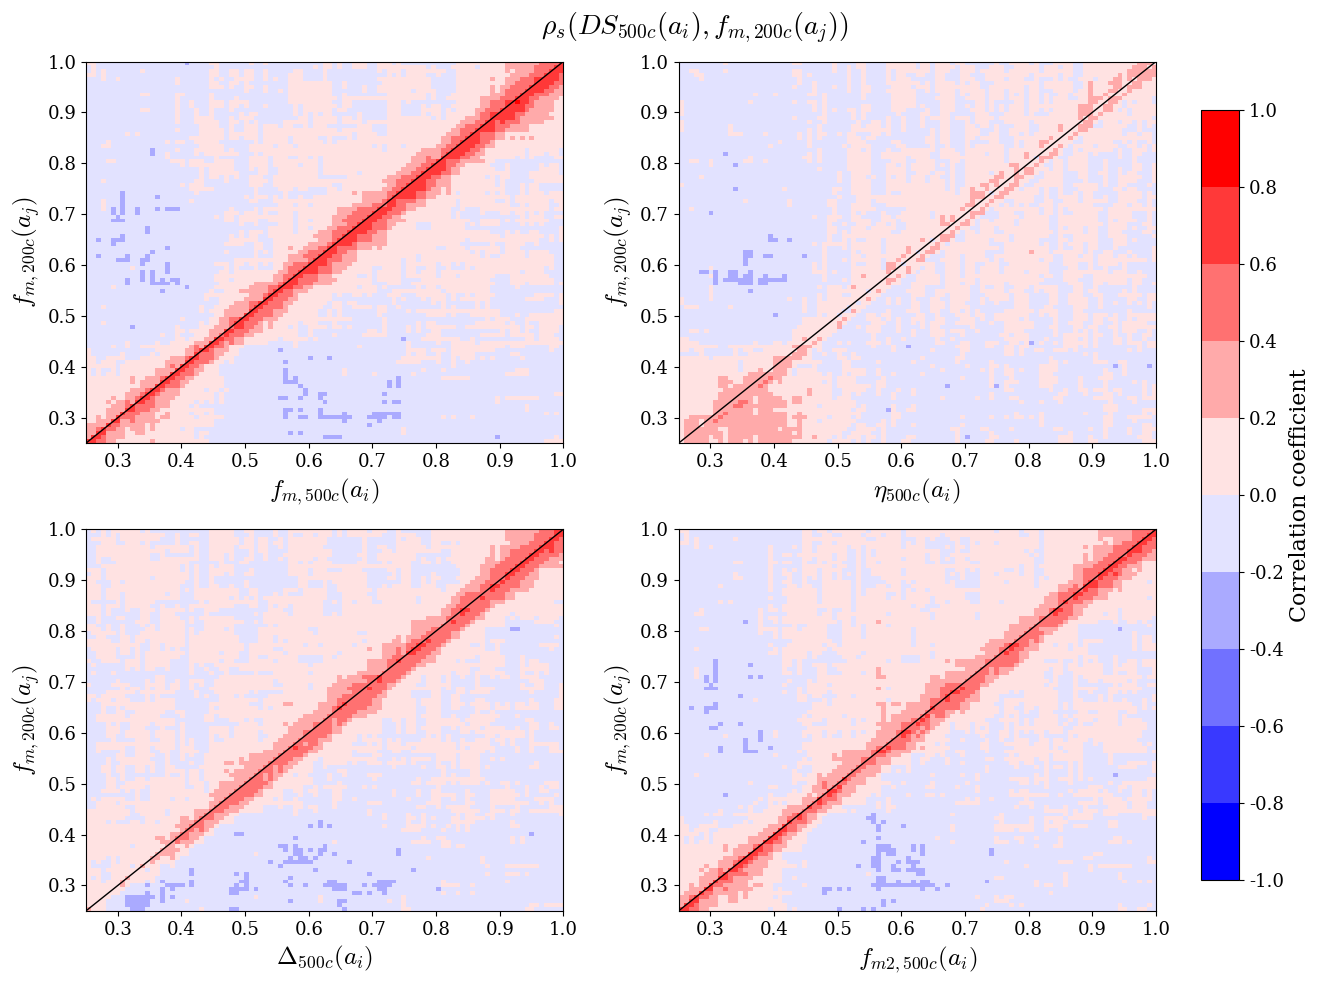

In [307]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

plot_2dcorr(fm500c, xlabel=r'$f_{m, 500c}(a_i)$',
            ylabel=r'$f_{m, 200c}(a_j)$',
            ax=axs[0, 0])

plot_2dcorr(eta500c, xlabel=r'$\eta_{500c}(a_i)$',
            ylabel=r'$f_{m, 200c}(a_j)$',
            ax=axs[0, 1])

plot_2dcorr(delta500c, xlabel=r'$\Delta_{500c}(a_i)$',
            ylabel=r'$f_{m, 200c}(a_j)$',
            ax=axs[1, 0])

# Get handle to the image from the last plot
im, boundaries = plot_2dcorr(fm2500c, xlabel=r'$f_{m2, 500c}(a_i)$',
                             ylabel=r'$f_{m, 200c}(a_j)$',
                             ax=axs[1, 1])

# Adjust layout before adding colorbar

# Add colorbar spanning all subplots
cbar = fig.colorbar(im, ax=axs.ravel().tolist(),
                    boundaries=boundaries, ticks=boundaries,
                    location='right', fraction=0.05)

cbar.ax.set_yticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label('Correlation coefficient', fontsize=16)
fig.suptitle(r'$\rho_s (DS_{500c}(a_i), f_{m, 200c}(a_j))$', fontsize=20)

plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar
plt.savefig('plots/ds_500c_fm_200c.pdf')
plt.show()

In [366]:
fm_corrs = []
eta_corrs = []
delta_corrs = []
fm2_corrs = []
for snap, df in dsdict_200.items():
    fm200 = df['fm_200[5]'].values
    eta200 = df['eta_200[3]'].values
    delta200 = df['delta_200[4]'].values
    fm2200 = df['fm2_200[6]'].values
    for time, df1 in dsdict_200.items():
        df1 = df1.copy()
        df1['fm_200'] = fm200
        df1['eta_200'] = eta200
        df1['delta_200'] = delta200
        df1['fm2_200'] = fm2200
        corr = df1.corr(method='spearman')
        fm_corrs.append(corr['fm_200'].values)
        eta_corrs.append(corr['eta_200'].values)
        delta_corrs.append(corr['delta_200'].values)
        fm2_corrs.append(corr['fm2_200'].values)

fm_corrs = np.array(fm_corrs)
fm_corrs = fm_corrs.reshape(97, 97, 8)  # n_snaps, n_snaps, n_features

eta_corrs = np.array(eta_corrs).reshape(97, 97, 8)
delta_corrs = np.array(delta_corrs).reshape(97, 97, 8)
fm2_corrs = np.array(fm2_corrs).reshape(97, 97, 8)

In [367]:
eta200c = eta_corrs[:, :, 0]
delta200c = delta_corrs[:, :, 1]
fm200c = fm_corrs[:, :, 2]
fm2200c = fm2_corrs[:, :, 3]

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_24171/134900705.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar


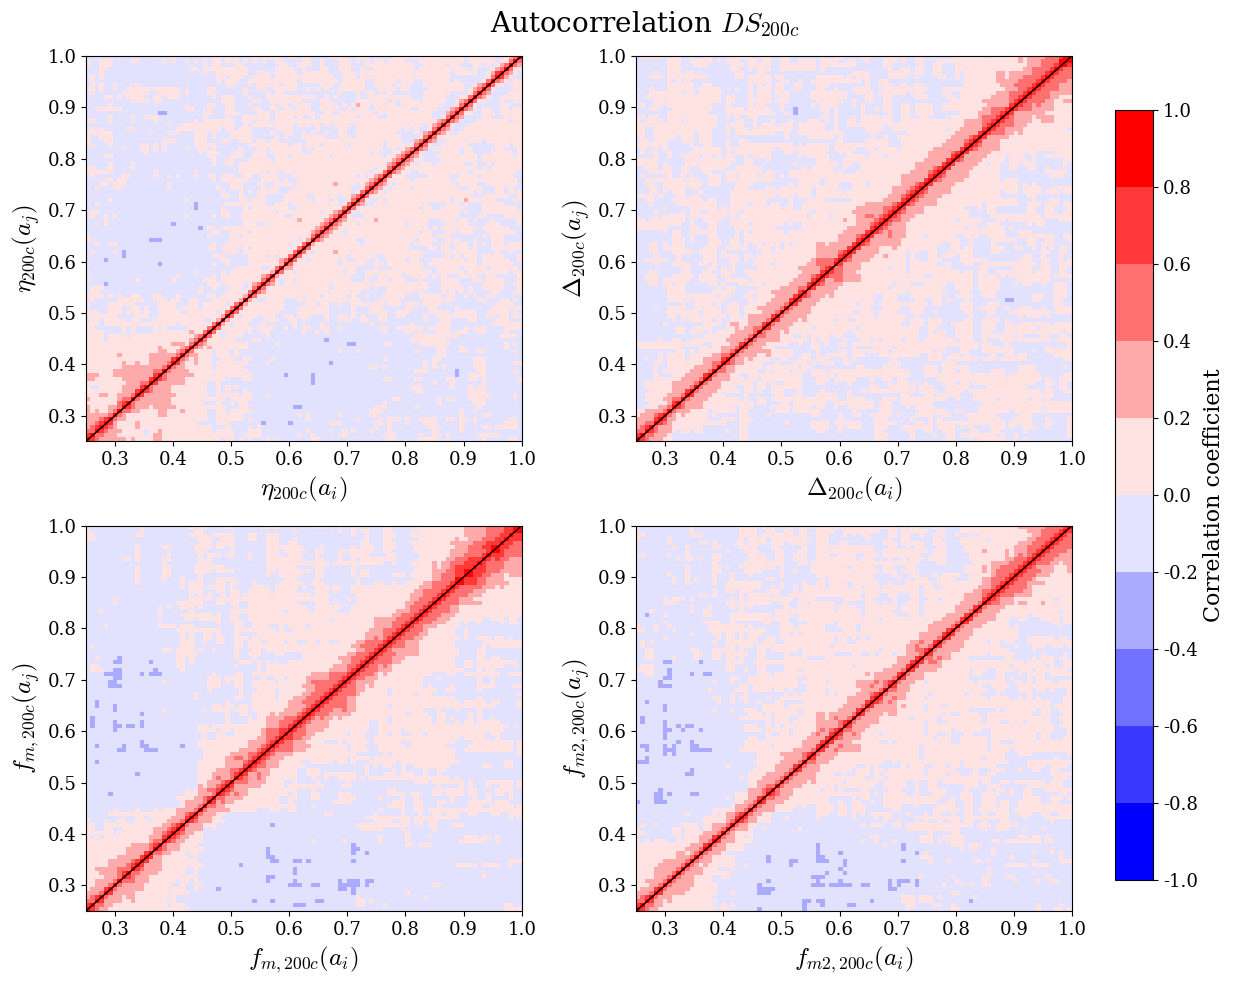

In [368]:
fig, axs = plt.subplots(2, 2, figsize=(13, 10))

plot_2dcorr(eta200c, xlabel=r'$\eta_{200c}(a_i)$',
            ylabel=r'$\eta_{200c}(a_j)$',
            ax=axs[0, 0])

plot_2dcorr(delta200c, xlabel=r'$\Delta_{200c}(a_i)$',
            ylabel=r'$\Delta_{200c}(a_j)$',
            ax=axs[0, 1])

plot_2dcorr(fm200c, xlabel=r'$f_{m, 200c}(a_i)$',
            ylabel=r'$f_{m, 200c}(a_j)$',
            ax=axs[1, 0])

# Get handle to the image from the last plot
im, boundaries = plot_2dcorr(fm2200c, xlabel=r'$f_{m2, 200c}(a_i)$',
                             ylabel=r'$f_{m2, 200c}(a_j)$',
                             ax=axs[1, 1])

# Adjust layout before adding colorbar

# Add colorbar spanning all subplots
cbar = fig.colorbar(im, ax=axs.ravel().tolist(),
                    boundaries=boundaries, ticks=boundaries,
                    location='right', fraction=0.05)

cbar.ax.set_yticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label('Correlation coefficient', fontsize=16)
fig.suptitle(r'Autocorrelation $DS_{200c}$', fontsize=20)

plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar
plt.savefig('plots/ds_200c_auto.pdf')
plt.show()

In [369]:
fm_corrs = []
eta_corrs = []
delta_corrs = []
fm2_corrs = []
for snap, df in dsdict_500.items():
    fm500 = df['fm_500[10]'].values
    eta500 = df['eta_500[8]'].values
    delta500 = df['delta_500[9]'].values
    fm2500 = df['fm2_500[11]'].values
    for time, df1 in dsdict_500.items():
        df1 = df1.copy()
        df1['fm_500'] = fm500
        df1['eta_500'] = eta500
        df1['delta_500'] = delta500
        df1['fm2_500'] = fm2500
        corr = df1.corr(method='spearman')
        fm_corrs.append(corr['fm_500'].values)
        eta_corrs.append(corr['eta_500'].values)
        delta_corrs.append(corr['delta_500'].values)
        fm2_corrs.append(corr['fm2_500'].values)

fm_corrs = np.array(fm_corrs)
fm_corrs = fm_corrs.reshape(97, 97, 8)  # n_snaps, n_snaps, n_features

eta_corrs = np.array(eta_corrs).reshape(97, 97, 8)
delta_corrs = np.array(delta_corrs).reshape(97, 97, 8)
fm2_corrs = np.array(fm2_corrs).reshape(97, 97, 8)

In [370]:
eta500c = eta_corrs[:, :, 0]
delta500c = delta_corrs[:, :, 1]
fm500c = fm_corrs[:, :, 2]
fm2500c = fm2_corrs[:, :, 3]

/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_24171/1429590924.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar


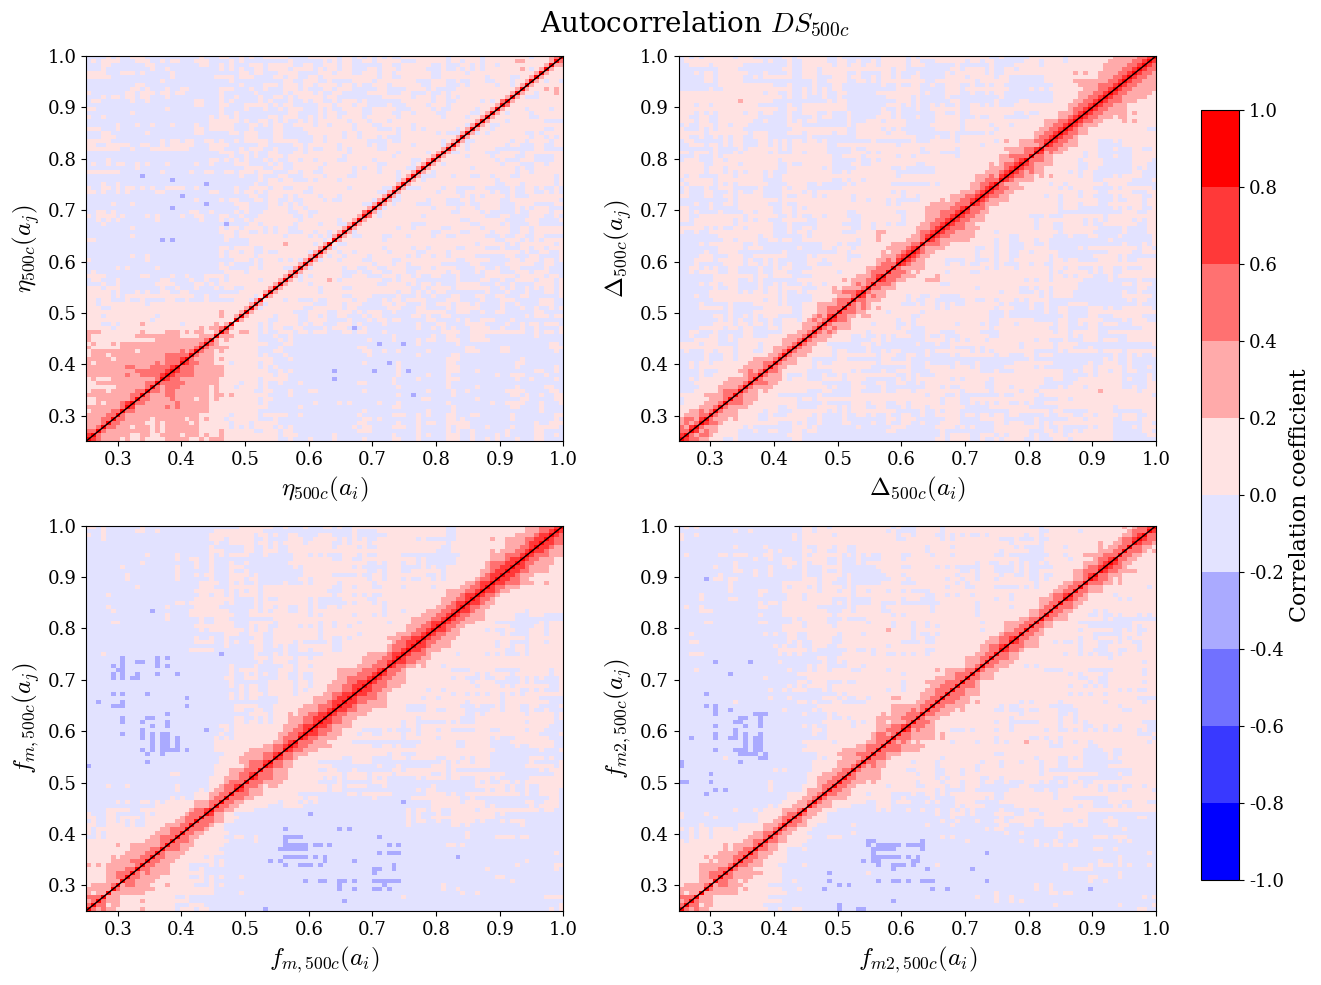

In [371]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

plot_2dcorr(eta500c, xlabel=r'$\eta_{500c}(a_i)$',
            ylabel=r'$\eta_{500c}(a_j)$',
            ax=axs[0, 0])

plot_2dcorr(delta500c, xlabel=r'$\Delta_{500c}(a_i)$',
            ylabel=r'$\Delta_{500c}(a_j)$',
            ax=axs[0, 1])

plot_2dcorr(fm500c, xlabel=r'$f_{m, 500c}(a_i)$',
            ylabel=r'$f_{m, 500c}(a_j)$',
            ax=axs[1, 0])

# Get handle to the image from the last plot
im, boundaries = plot_2dcorr(fm2500c, xlabel=r'$f_{m2, 500c}(a_i)$',
                             ylabel=r'$f_{m2, 500c}(a_j)$',
                             ax=axs[1, 1])

# Adjust layout before adding colorbar

# Add colorbar spanning all subplots
cbar = fig.colorbar(im, ax=axs.ravel().tolist(),
                    boundaries=boundaries, ticks=boundaries,
                    location='right', fraction=0.05)

cbar.ax.set_yticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label('Correlation coefficient', fontsize=16)
fig.suptitle(r'Autocorrelation $DS_{500c}$', fontsize=20)

plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar
plt.savefig('plots/ds_500c_auto.pdf')
plt.show()

In [7]:
mah_dict = futils.get_mah_all()
mah, common_aexp = datutils.interp_ma(mah_dict, num_scales=97)
reduced_ds_dict = {}
for k, df in dsdict.items():
    reduced_ds_dict[k] = df.loc[mah_dict.keys()]

In [8]:
rdsdict_200 = {}
rdsdict_500 = {}
for i, (snap, df) in enumerate(reduced_ds_dict.items()):
    rdsdict_200[snap] = df.drop(columns=['snap', 'eta_500[8]',
                                        'delta_500[9]', 'fm_500[10]', 'fm2_500[11]'])
    rdsdict_200[snap]['m(a)'] = mah[:, i]
    
    rdsdict_500[snap] = df.drop(columns=['snap', 'eta_200[3]',
                                        'delta_200[4]', 'fm_200[5]', 'fm2_200[6]'])

In [43]:
eta200c, delta200c, fm200c, fm2200c = [], [], [], []
for i, df in enumerate(rdsdict_200.values()):
    ma = df['m(a)'].values
    for j, df1 in enumerate(rdsdict_200.values()):
        ma_eta, _ = spearmanr(df1['eta_200[3]'].values, ma, nan_policy='omit')
        eta200c.append(ma_eta)

        ma_delta, _ = spearmanr(df1['delta_200[4]'].values, ma, nan_policy='omit')
        delta200c.append(ma_delta)

        ma_fm, _ = spearmanr(df1['fm_200[5]'].values, ma, nan_policy='omit')
        fm200c.append(ma_fm)

        ma_fm2200, _ = spearmanr(df1['fm2_200[6]'].values, ma, nan_policy='omit')
        fm2200c.append(ma_fm2200)

eta200c = np.array(eta200c).reshape(97, 97)
delta200c = np.array(delta200c).reshape(97, 97)
fm200c = np.array(fm200c).reshape(97, 97)
fm2200c = np.array(fm2200c).reshape(97, 97)

ma_corrs, _ = spearmanr(mah, axis=0)

$t_{dyn} = \sqrt{\frac{R_{200}^3}{G*M_{200}}} = \frac{1}{10H_0}$

$H_0 = 67.8 \mathrm{kms}^{-1}{\mathrm{Mpc}^{-1}}$ in The300 simulations

In [105]:
t_d = (3.0857e19)/(10*Planck13.H0.value*60*60*24*365e9)
print(f'Dynamical time = {t_d:.2f} Gyr')

redshift_list = pd.read_csv('data/gadgetx3k/redshift_list.txt', sep=r'\s+')
scales = redshift_list[66:]['a'].values     # for some reason I am only getting values after a>0.25
redshifts = redshift_list[66:]['z'].values
lookback_time = Planck13.lookback_time(redshifts).value  # in Gyr
lookback_time_td = lookback_time / t_d

Dynamical time = 1.44 Gyr


/var/folders/rs/w1_w_dfd5v3cjbx220100ydh0000gn/T/ipykernel_98649/3214434396.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar


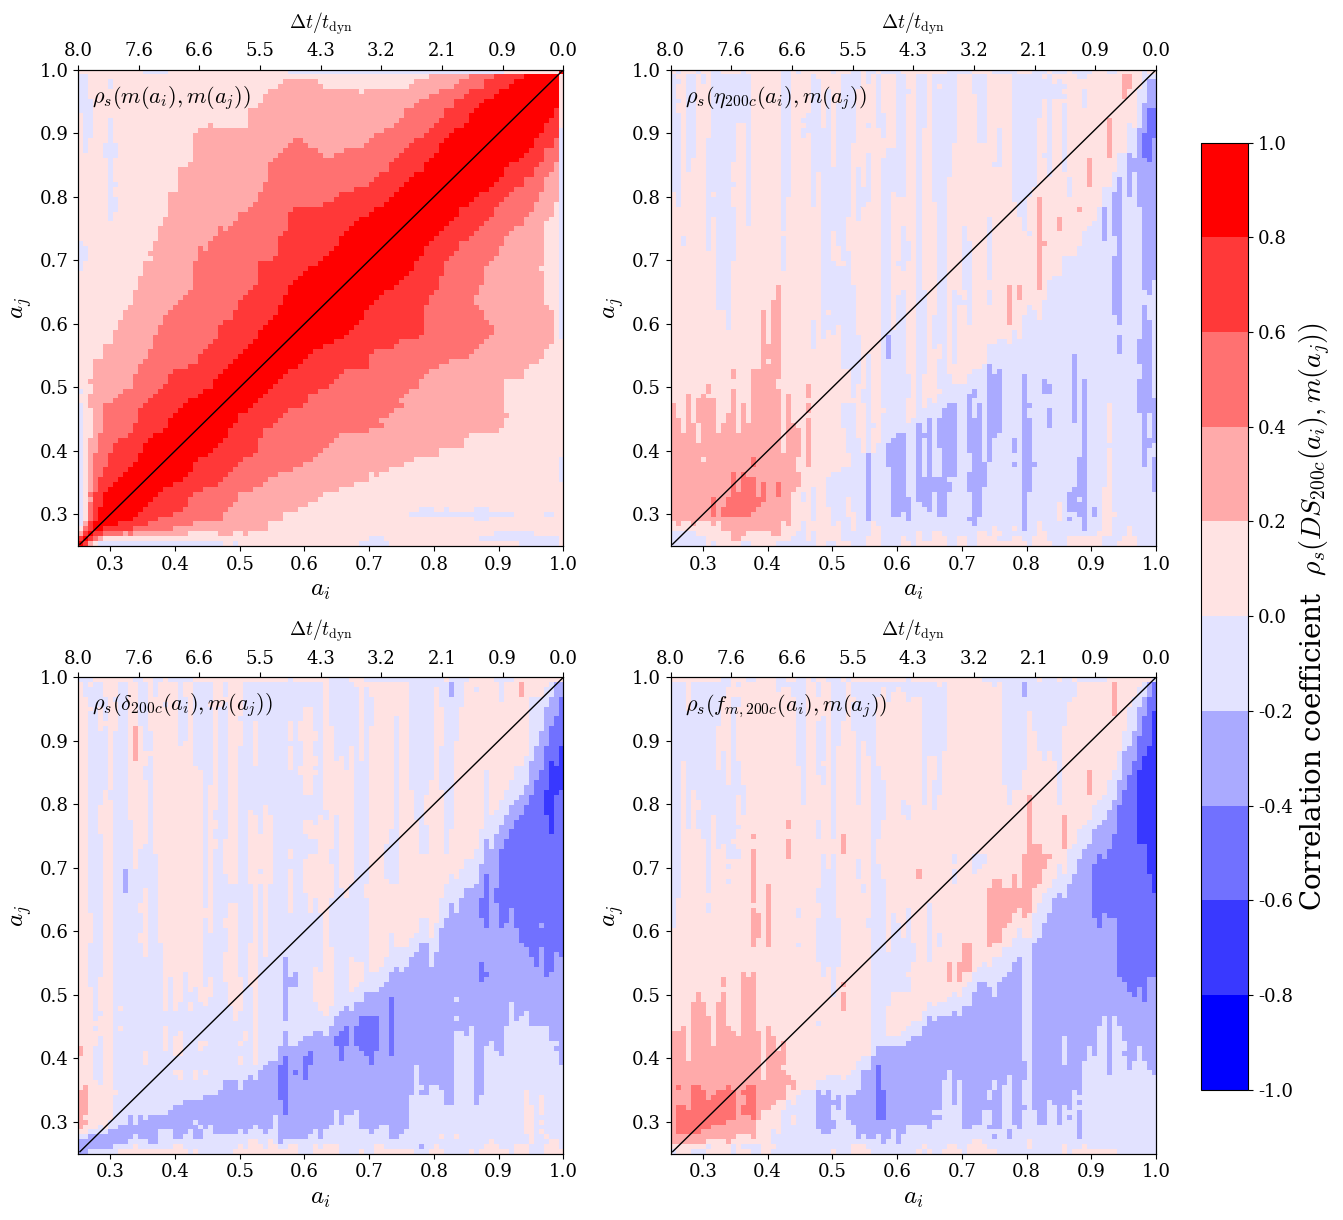

In [155]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12.3))

plot_2dcorr(ma_corrs, scales=scales, xlabel=r'$a_i$',
            ylabel=r'$a_j$',
            ax=axs[0, 0])
axs[0, 0].annotate(r'$\rho_s (m(a_i), m(a_j))$', xy=(0.03, 0.93), xycoords='axes fraction',
                   fontsize=16)

plot_2dcorr(eta200c, scales=scales, xlabel=r'$a_i$',
            ylabel=r'$a_j$',
            ax=axs[0, 1])
axs[0, 1].annotate(r'$\rho_s (\eta_{200c}(a_i), m(a_j))$', xy=(0.03, 0.93), xycoords='axes fraction',
                   fontsize=16)

plot_2dcorr(delta200c, scales=scales, xlabel=r'$a_i$',
            ylabel=r'$a_j$',
            ax=axs[1, 0])
axs[1, 0].annotate(r'$\rho_s (\delta_{200c}(a_i), m(a_j))$', xy=(0.03, 0.93), xycoords='axes fraction',
                   fontsize=16)
# Get handle to the image from the last plot
im, boundaries = plot_2dcorr(fm200c, scales=scales, xlabel=r'$a_i$',
                             ylabel=r'$a_j$',
                             ax=axs[1, 1])
axs[1, 1].annotate(r'$\rho_s (f_{m, 200c}(a_i), m(a_j))$', xy=(0.03, 0.93), xycoords='axes fraction',
                   fontsize=16)

# Add upper x-axes with lookback time labels
for ax in axs.ravel():
    ax_top = ax.twiny()  # create the twin axis
    ax_top.set_xlim(ax.get_xlim())  # match limits to bottom axis

    # match tick *positions* but replace tick *labels*
    ticks = ax.get_xticks()
    idx = np.searchsorted(scales, ticks)    # finds indices where ticks are in scales array
    ax_top.set_xticks(ticks)
    ax_top.set_xticklabels([f"{lookback_time_td[i]:.1f}" for i in idx])

    ax_top.set_xlabel(r'$\Delta t / t_{\mathrm{dyn}}$', fontsize=14, labelpad=10)

cbar = fig.colorbar(im, ax=axs.ravel().tolist(),
                    boundaries=boundaries, ticks=boundaries,
                    location='right', fraction=0.05)

cbar.ax.set_yticklabels([f'{b:.1f}' for b in boundaries])
cbar.set_label(
    r'Correlation coefficient  $\rho_s (DS_{200c}(a_i), m(a_j))$', fontsize=20)

plt.tight_layout(rect=[0, 0, 0.84, 1])  # leave space on right for colorbar
plt.savefig('plots/ds_200c_ma.pdf')
plt.show()

# MAH correlations

In [4]:
mah_df_dict = futils.get_mah_all('data/gadgetx3k/AHFHaloHistory/')
indxs = [k for k in mah_df_dict.keys()]
dsdf = futils.get_ds()
dsdf = dsdf.loc[indxs]

In [6]:
ma = np.array([df['M/M0'].values for _, df in mah_df_dict.items()])
scales = mah_df_dict[1]['aexp'].values
am, common_m = datutils.get_am(ma, scales=scales, min_mass_bin=0.005)

/Users/kabelo/clusters/utils/data.py:291: RuntimeWarning: invalid value encountered in log
  np.log(_m_peaks), np.log(_scales), bounds_error=False, fill_value=np.nan


In [ ]:
start = time.time()
ma_ds_dict, ma_corrs, filtered_z_list = corutils.build_ma_corrs(
    mah_df_dict, dsdf)
am_ds_dict, am_corrs = corutils.build_am_corrs(
    am, masses=common_m, df0=dsdf)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)
end = time.time()
print(f'{end-start:.1f}s')

11.6s


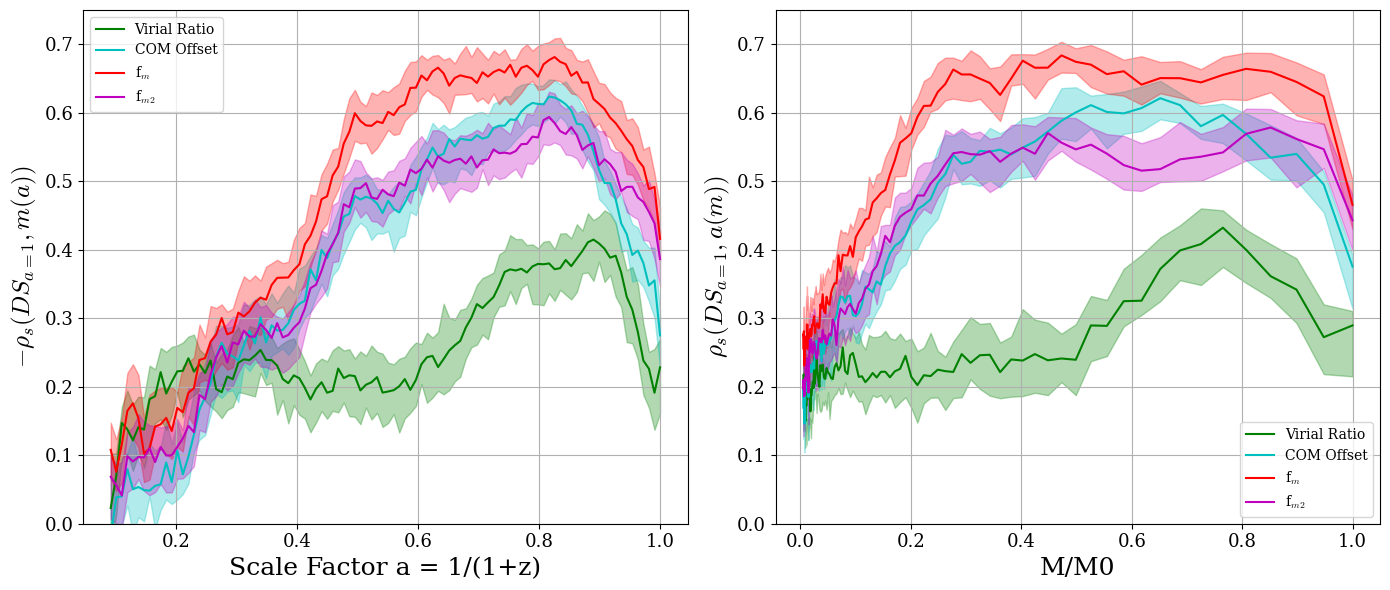

176.9s


In [ ]:
start = time.time()
colors = ['g', 'c', 'r', 'm', 'b', 'y']
labels = ['Virial Ratio', 'COM Offset', r'f$_m$', r'f$_{m2}$']
yticks = np.arange(0., 0.8, 0.1)
ylim = (0, 0.75)
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
for i, param in enumerate(dsdf.columns[:4]):

    p10, p25, p50, p75, p90 = datutils.get_percs(
        ma_ds_dict, param=param, history='M/M0')
    n10, n25, n50, n75, n90 = np.array(p10), np.array(p25), np.array(p50), np.array(p75), np.array(p90)
    # axs[0].set_title('m(a) correlations')
    axs[0].plot(aexp, -1*n50, color=colors[i], label=labels[i])
    # axs[0].fill_between(aexp, p10, p90, color=colors[i], alpha=0.2)
    axs[0].fill_between(aexp, -1*n25, -1*n75, color=colors[i], alpha=0.3)

    p10, p25, p50, p75, p90 = datutils.get_percs(
        am_ds_dict, param=param, history='am')
    # axs[1].set_title('a(m) correlations')
    axs[1].plot(common_m, p50, color=colors[i], label=labels[i])
    # axs[1].fill_between(common_m, p10, p90, color=colors[i], alpha=0.2)
    axs[1].fill_between(common_m, p25, p75, color=colors[i], alpha=0.3)

axs[0].set_xlabel('Scale Factor a = 1/(1+z)')
axs[0].set_ylabel(r'$-\rho_s (DS_{a=1}, m(a))$')
axs[0].set_yticks(yticks)
axs[0].set_ylim(ylim)
axs[0].grid()
axs[0].legend()

axs[1].set_xlabel('M/M0')
axs[1].set_ylabel(r'$\rho_s (DS_{a=1}, a(m))$')
axs[1].set_yticks(yticks)
axs[1].set_ylim(ylim)
axs[1].grid()
axs[1].legend()
plt.tight_layout()
plt.savefig('plots/ds_mah_corrs.pdf')
plt.show()

end = time.time()
print(f'{end-start:.1f}s')

In [26]:
ahf = futils.get_ahf(
    'data/gadgetx3k/AHFHaloHistory/NewMDCLUSTER_0012_halo_128000000000001.dat')

In [30]:
ahf[['Redshift(0)','Mvir(4)', 'ovdens(36)']]

,Redshift(0),Mvir(4),ovdens(36)
107,9.651,2.163600e+10,168.49
106,9.454,2.314140e+10,167.76
105,9.165,2.567960e+10,187.69
104,8.977,3.019580e+10,192.17
103,8.792,3.297040e+10,155.30
...,...,...,...
4,0.092,1.403570e+15,200.00
3,0.068,1.493980e+15,200.00
2,0.044,1.544730e+15,200.00
1,0.021,1.549010e+15,200.00
